In [1]:
import mudata
import pandas as pd
import numpy as np
from PyComplexHeatmap import *

In [2]:

scplus_mdata = mudata.read("../process/20241226_scenicplus_outs/scplusmdata.h5mu")

/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/zhanglab/micromamba

In [3]:
import scanpy as sc
import anndata
eRegulon_gene_AUC = anndata.concat(
    [scplus_mdata["direct_gene_based_AUC"], scplus_mdata["extended_gene_based_AUC"]],
    axis = 1,
)

In [4]:
eRegulon_gene_AUC.obs = scplus_mdata.obs.loc[eRegulon_gene_AUC.obs_names]
sc.pp.neighbors(eRegulon_gene_AUC, use_rep = "X")
sc.tl.umap(eRegulon_gene_AUC)

In [5]:
sc.settings.figdir = "../result/regulation/20241226_scenicplus_paired/"

In [6]:
!mkdir ../result/regulation/20241226_scenicplus_paired/

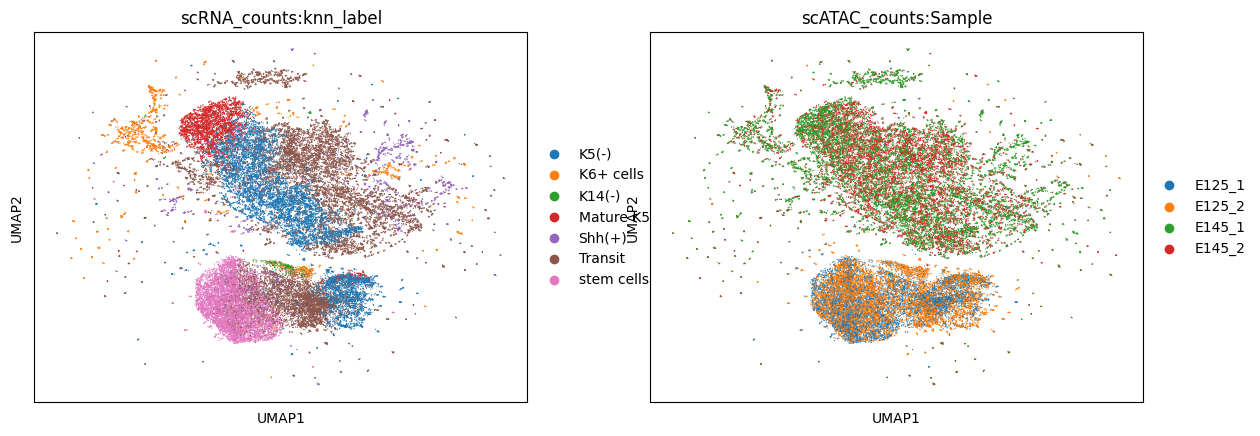

In [9]:
sc.pl.umap(eRegulon_gene_AUC, color = ["scRNA_counts:knn_label","scATAC_counts:Sample"],save="_reduction.pdf")

In [6]:
from scenicplus.RSS import (regulon_specificity_scores, plot_rss)

In [7]:
rss = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scRNA_counts:knn_label",
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"]
)

In [8]:
rss

,Atf1_direct_+/-_(56g),Atf3_direct_+/+_(485g),Atf3_direct_-/-_(30g),Atf4_direct_+/-_(75g),Atf6_direct_+/-_(12g),Atf7_direct_+/+_(10g),Bach1_direct_+/+_(299g),Cebpa_direct_+/+_(28g),Cebpb_direct_+/+_(235g),Cebpg_direct_+/+_(27g),...,Zfp398_extended_+/-_(11g),Zfp444_extended_+/-_(11g),Zfp511_extended_+/-_(18g),Zfp637_extended_+/+_(17g),Zfp64_extended_+/+_(30g),Zfp654_extended_+/+_(271g),Zfp654_extended_+/-_(39g),Zfp704_extended_+/-_(229g),Zfp740_extended_+/-_(36g),Zgpat_extended_+/-_(13g)
K5(-),0.396184,0.382563,0.341280,0.385577,0.229196,0.191581,0.369436,0.258006,0.358228,0.251560,...,0.173411,0.204227,0.305664,0.377353,0.392493,0.309131,0.281440,0.362911,0.419324,0.200230
stem cells,0.349045,0.286461,0.445022,0.340182,0.267632,0.187258,0.312170,0.349029,0.316811,0.349209,...,0.192623,0.212752,0.227589,0.349164,0.328570,0.433223,0.462035,0.331462,0.290215,0.191988
Mature K5(-),0.237164,0.278849,0.227824,0.251941,0.193393,0.219496,0.274615,0.198059,0.260339,0.197513,...,0.184285,0.214835,0.267831,0.255476,0.254391,0.231255,0.215862,0.279463,0.292205,0.208689
Transit,0.461919,0.466173,0.405111,0.467987,0.247354,0.274004,0.475543,0.487609,0.458861,0.490365,...,0.216301,0.224013,0.375322,0.465122,0.473677,0.398264,0.349714,0.440476,0.416569,0.296201
Shh(+),0.207876,0.223445,0.197129,0.215209,0.183677,0.195979,0.225366,0.244298,0.221638,0.233059,...,0.249034,0.200086,0.235333,0.218243,0.211066,0.198982,0.190875,0.217551,0.198893,0.197033
K6+ cells,0.225436,0.255856,0.207866,0.234274,0.220336,0.361903,0.239780,0.261188,0.282335,0.252382,...,0.262358,0.228454,0.251122,0.229669,0.228275,0.208971,0.200979,0.226635,0.235678,0.217139
K14(-),0.178113,0.177807,0.183757,0.179198,0.240867,0.201932,0.178628,0.182262,0.186229,0.185245,...,0.185247,0.179413,0.176000,0.179546,0.177353,0.189098,0.187635,0.181621,0.174494,0.177629


In [9]:
snap_umap = pd.read_csv("../process/framework/reduction/20241222_snapatac_umap.csv",index_col=0)

In [10]:
snap_index = snap_umap.index

In [11]:
def transform_barcode(barcode):
    # Split by ':' to separate sample and barcode sequence
    sample, barcode_seq = barcode.split(':')
    # Create new format: barcode-sample___sample
    return f"{barcode_seq}-{sample}___{sample}"


# Example usage:
old_barcodes = snap_index
new_barcodes = [transform_barcode(x) for x in old_barcodes]


In [12]:
snap_umap.index = new_barcodes

In [13]:
snap_umap_sub = snap_umap.loc[eRegulon_gene_AUC.obs_names]

In [14]:
eRegulon_gene_AUC.obsm["X_umap_snap"] = np.array(snap_umap_sub)

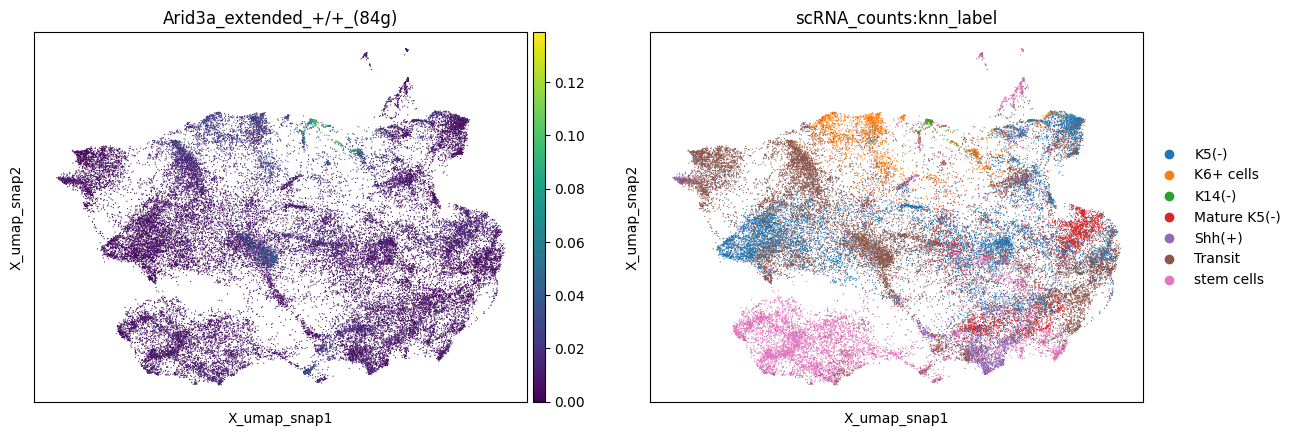

In [15]:
sc.pl.embedding(eRegulon_gene_AUC, color= ["Arid3a_extended_+/+_(84g)","scRNA_counts:knn_label"],
                basis="X_umap_snap",save="_arid3a_snap_reduction.pdf")

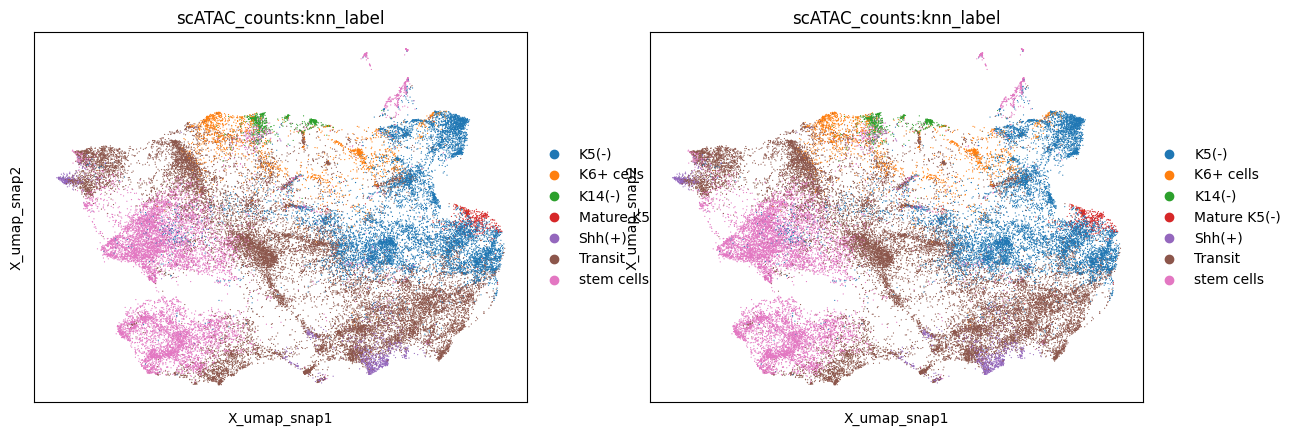

In [16]:
sc.pl.embedding(eRegulon_gene_AUC, color= ["scATAC_counts:knn_label","scATAC_counts:knn_label"],
                basis="X_umap_snap",save="_pseudopair_snap_reduction_atac_label.pdf")

/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scanpy/plotting/_utils.py:338: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(filename, dpi=dpi, bbox_inches="tight")
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scanpy/plotting/_utils.py:338: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(filename, dpi=dpi, bbox_inches="tight")
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


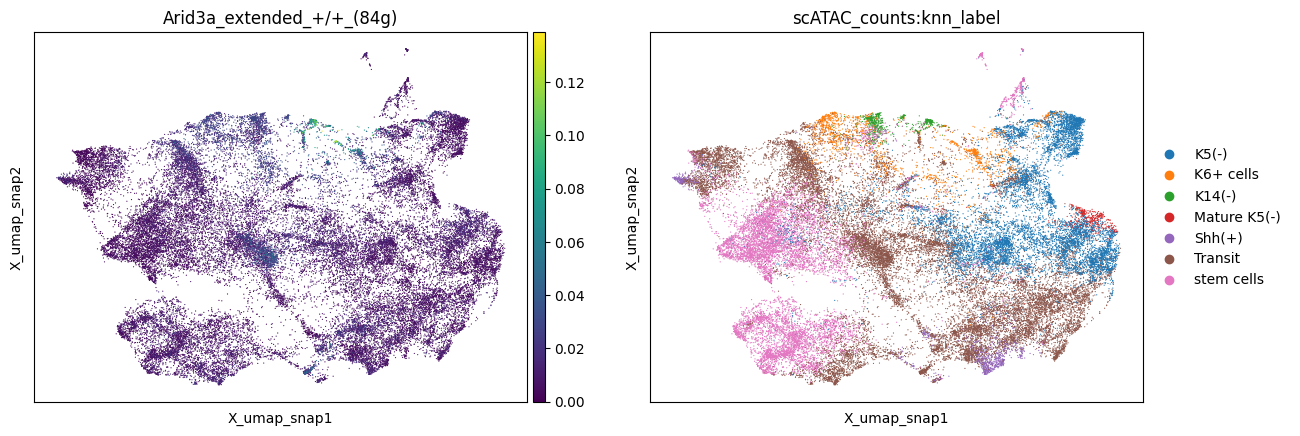

In [64]:
sc.pl.embedding(eRegulon_gene_AUC, color= ["Arid3a_extended_+/+_(84g)","scATAC_counts:knn_label"],
                basis="X_umap_snap",save="_arid3a_snap_atac_reduction.pdf")

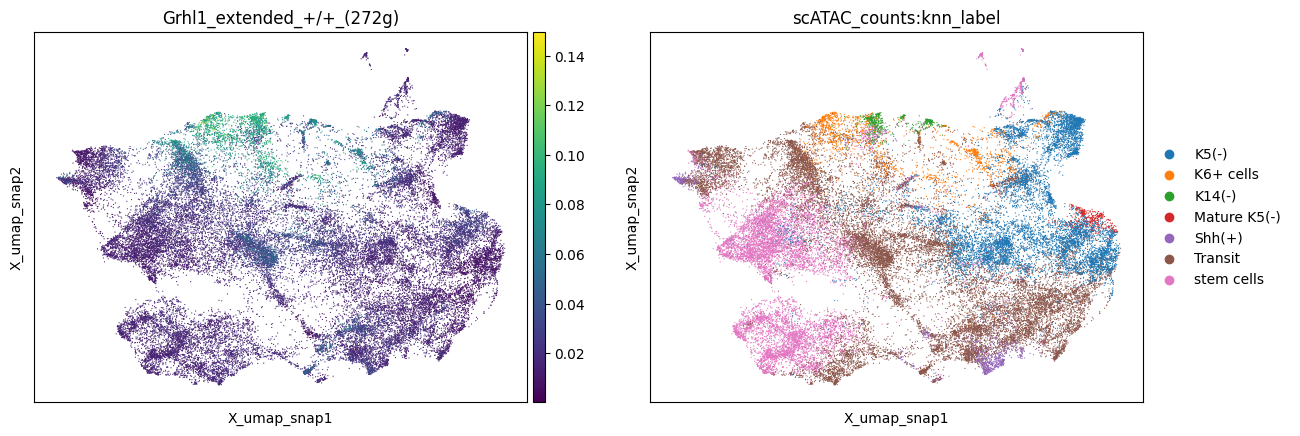

In [17]:
sc.pl.embedding(eRegulon_gene_AUC, color= ["Grhl1_extended_+/+_(272g)","scATAC_counts:knn_label"],
                basis="X_umap_snap",save="_grhl1_snap_atac_reduction.pdf")

In [15]:
rss.loc["K6+ cells"].sort_values(ascending=False)[0:30]

Grhl1_extended_+/-_(33g)     0.391999
Hmga2_extended_-/-_(13g)     0.387121
Atf7_extended_+/+_(16g)      0.384320
Foxq1_extended_+/-_(66g)     0.382819
Foxq1_extended_+/+_(74g)     0.362426
Atf7_direct_+/+_(10g)        0.361903
Ehf_extended_+/-_(11g)       0.356815
Grhl1_extended_+/+_(272g)    0.342959
Foxo3_extended_+/-_(21g)     0.342455
Smad3_direct_+/+_(37g)       0.342413
Ahr_extended_+/-_(123g)      0.332023
Mtf1_extended_+/-_(13g)      0.320186
Arid3a_extended_+/+_(84g)    0.319889
Ets1_extended_+/+_(20g)      0.314271
Nfe2l2_direct_+/+_(57g)      0.313344
Grhl3_extended_+/+_(196g)    0.310269
Patz1_extended_+/+_(13g)     0.308241
Maff_direct_+/+_(217g)       0.303763
Cebpb_extended_+/-_(99g)     0.300697
Barx2_extended_+/-_(57g)     0.298580
Maff_extended_+/+_(117g)     0.296869
Fosb_direct_+/+_(203g)       0.290656
Klf3_direct_+/-_(220g)       0.288000
Six4_direct_+/+_(35g)        0.286983
Fos_direct_+/+_(255g)        0.286900
Fos_extended_+/+_(255g)      0.286407
Klf3_extende

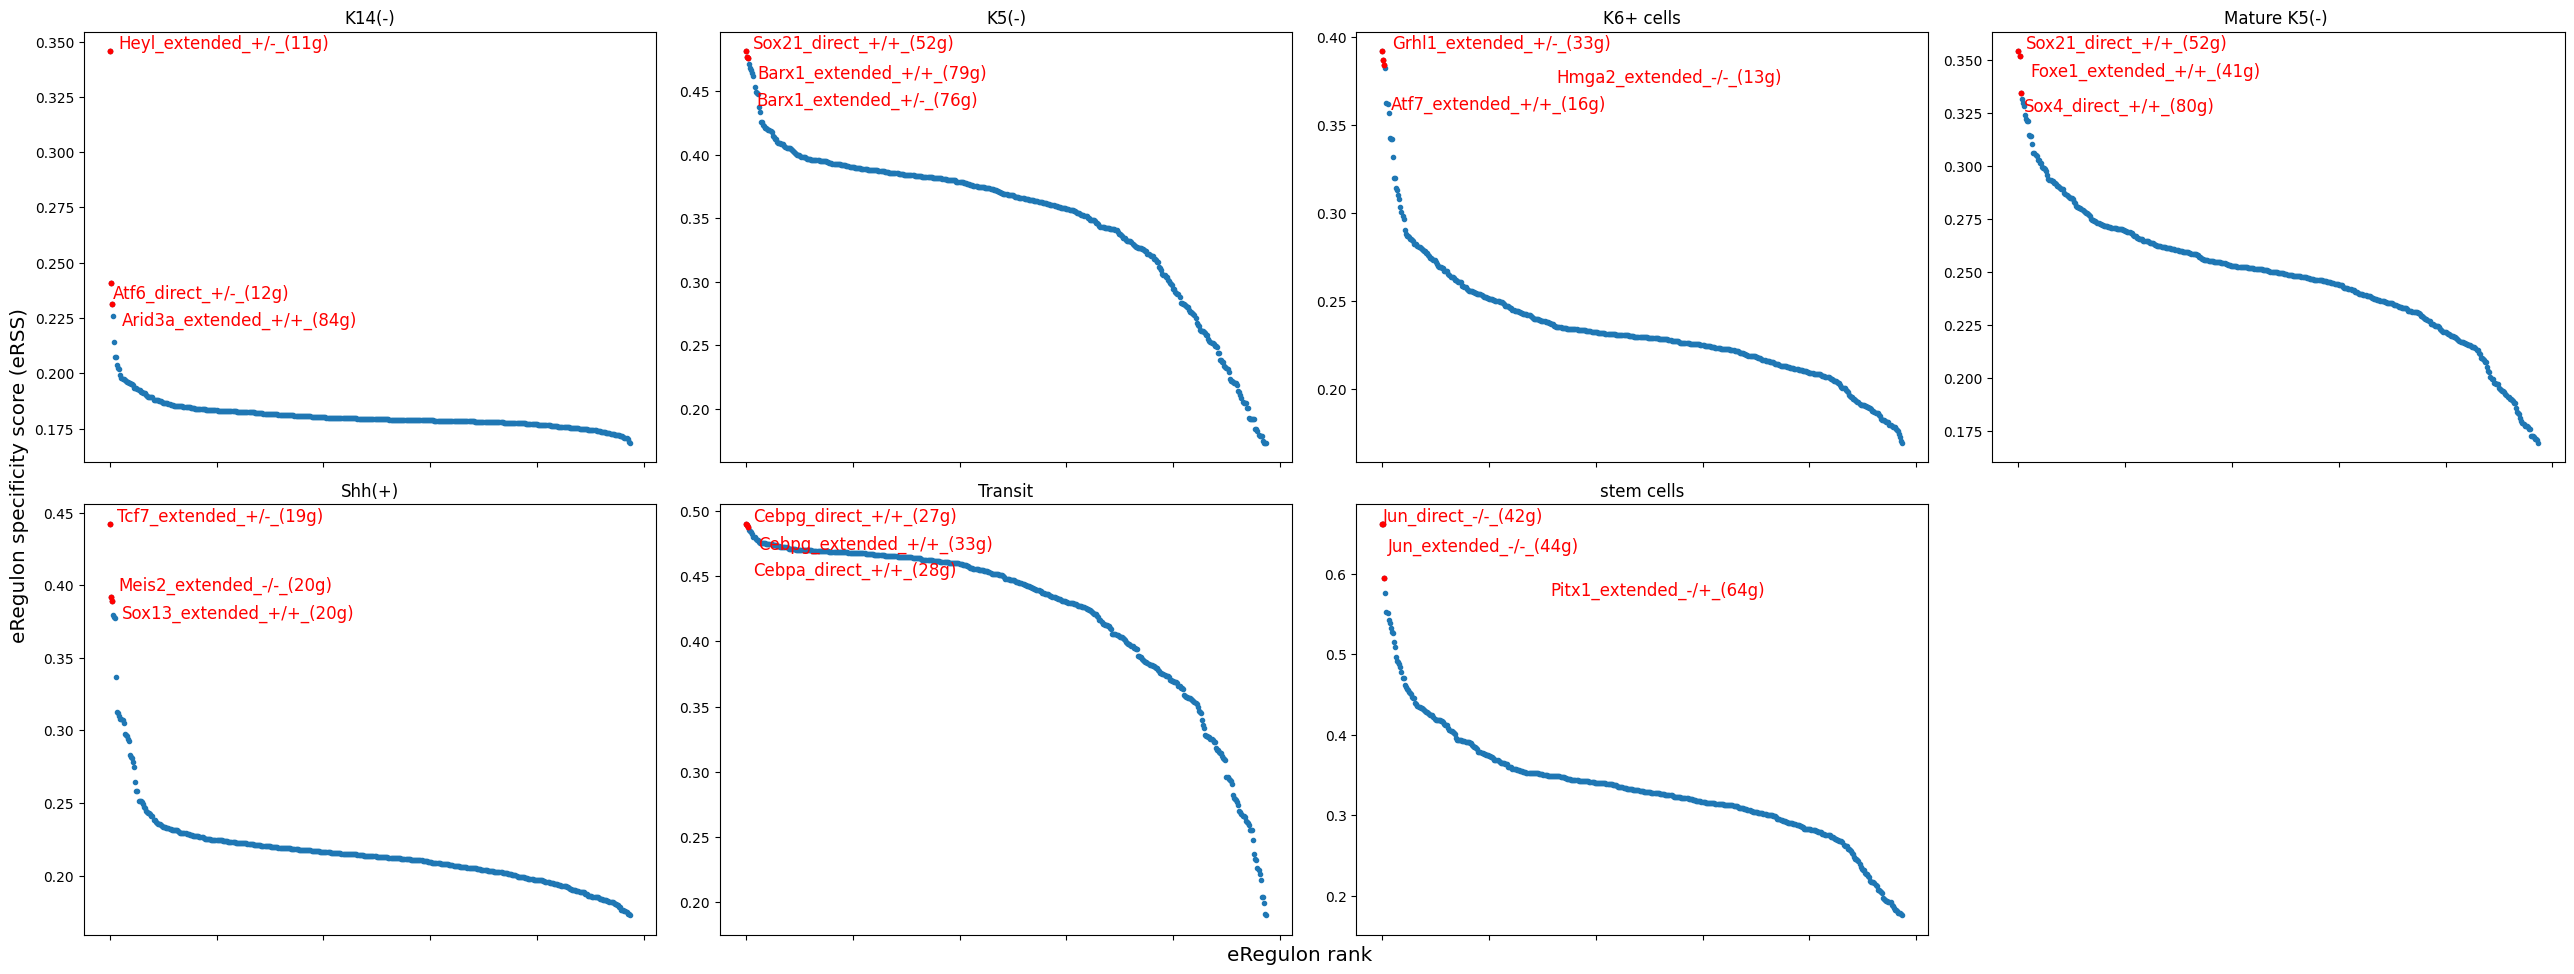

In [16]:
plot_rss(
    data_matrix = rss,
    top_n = 3,
    num_columns = 4,save="../result/regulation/20241226_scenicplus_paired/regulon_rss.pdf"
)

In [101]:
rss_origin = pd.read_csv("../result/regulation/20241221_scenicplus/20241221_rss_table.csv",index_col=0)

In [102]:
rss_origin = rss_origin.T

In [103]:
rss_origin.index

Index(['Atf2_direct_+/+_(29g)', 'Atf2_direct_+/-_(71g)',
       'Atf3_direct_+/+_(961g)', 'Atf3_direct_+/-_(237g)',
       'Atf3_direct_-/-_(50g)', 'Atf4_direct_+/+_(106g)',
       'Atf4_direct_+/-_(13g)', 'Bach1_direct_+/+_(146g)',
       'Bach2_direct_+/+_(194g)', 'Cebpb_direct_+/+_(279g)',
       ...
       'Zfp148_extended_+/-_(511g)', 'Zfp207_extended_+/+_(138g)',
       'Zfp219_extended_+/+_(40g)', 'Zfp398_extended_+/+_(10g)',
       'Zfp407_extended_+/+_(20g)', 'Zfp637_extended_+/-_(15g)',
       'Zfp64_extended_+/-_(69g)', 'Zfp704_extended_+/-_(203g)',
       'Zfp740_extended_+/-_(22g)', 'Zfp770_extended_+/-_(11g)'],
      dtype='object', length=502)

In [19]:
def transform_tf_name(name):
    # Split by '_' and take first two parts
    base_name = '_'.join(name.split('_')[:3])
    return base_name

# Apply to list
new_names = [transform_tf_name(x) for x in rss_origin.index]

NameError: name 'rss_origin' is not defined

In [105]:
rss_origin.index = new_names

In [22]:
rss_transpose = rss.T
new_names2 = [transform_tf_name(x) for x in rss_transpose.index]
rss_transpose.index = new_names2

In [23]:
rss_transpose

,K5(-),stem cells,Mature K5(-),Transit,Shh(+),K6+ cells,K14(-)
Atf1_direct_+/-,0.396184,0.349045,0.237164,0.461919,0.207876,0.225436,0.178113
Atf3_direct_+/+,0.382563,0.286461,0.278849,0.466173,0.223445,0.255856,0.177807
Atf3_direct_-/-,0.341280,0.445022,0.227824,0.405111,0.197129,0.207866,0.183757
Atf4_direct_+/-,0.385577,0.340182,0.251941,0.467987,0.215209,0.234274,0.179198
Atf6_direct_+/-,0.229196,0.267632,0.193393,0.247354,0.183677,0.220336,0.240867
...,...,...,...,...,...,...,...
Zfp654_extended_+/+,0.309131,0.433223,0.231255,0.398264,0.198982,0.208971,0.189098
Zfp654_extended_+/-,0.281440,0.462035,0.215862,0.349714,0.190875,0.200979,0.187635
Zfp704_extended_+/-,0.362911,0.331462,0.279463,0.440476,0.217551,0.226635,0.181621
Zfp740_extended_+/-,0.419324,0.290215,0.292205,0.416569,0.198893,0.235678,0.174494


In [24]:
K6_reg = rss_transpose.loc[:,"K6+ cells"].sort_values(ascending=False)[0:30].index

## Plot dotplot

In [20]:
import matplotlib.pyplot as plt

Size matrix columns: Index(['Acaa1b_extended_+/+_(12g)', 'Ahr_extended_+/-_(123g)',
       'Arid3a_extended_+/+_(84g)', 'Arid5b_extended_+/+_(29g)',
       'Arid5b_extended_+/-_(18g)'],
      dtype='object')
Color matrix columns: Index(['Acaa1b_extended_+/+_(14r)', 'Ahr_extended_+/-_(169r)',
       'Arid3a_extended_+/+_(117r)', 'Arid5b_extended_+/+_(36r)',
       'Arid5b_extended_+/-_(23r)'],
      dtype='object')
Size features (first 5): ['Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)']
Color features (first 5): ['Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)']
Metadata columns: Index(['Region', 'Gene', 'importance_R2G', 'rho_R2G', 'importance_x_rho',
       'importance_x_abs_rho', 'TF', 'is_extended', 'eRegulon_name',
       'Gene_signature_name', 'Region_signature_name', 'importance_TF2G',
       'regulation', 'rho_TF2

/tmp/ipykernel_2191701/3891636644.py:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2191701/3891636644.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:356: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
/home/zhanglab/micromamba/envs

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 314.6483774002517
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/tmp/ipykernel_2191701/3891636644.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


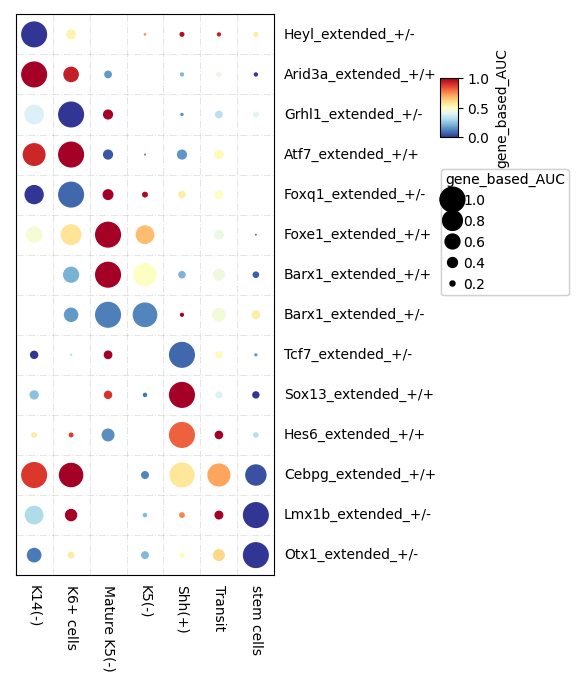

In [26]:

sizeMat = scplus_mdata["extended_gene_based_AUC"].to_df()
colorMat = scplus_mdata["extended_region_based_AUC"].to_df()
group_by = scplus_mdata.obs["scRNA_counts:knn_label"].tolist()
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
size_features = regulon_metadata["Region_signature_name"].tolist()
color_features = regulon_metadata["Gene_signature_name"].tolist()
feature_names = regulon_metadata["eRegulon_name"].tolist()
# First, check the actual column names in your matrices
from scenicplus.plotting.dotplot import generate_dotplot_df
# First, check the actual column names in your matrices
print("Size matrix columns:", sizeMat.columns[:5])  # Print first 5 columns
print("Color matrix columns:", colorMat.columns[:5])

# Check the feature names you're trying to use
print("Size features (first 5):", size_features[:5])
print("Color features (first 5):", color_features[:5])

# Get the correct feature names from metadata
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
print("Metadata columns:", regulon_metadata.columns)

# Make sure features match exactly
size_features = regulon_metadata["Gene_signature_name"].drop_duplicates().tolist()
color_features = regulon_metadata["Region_signature_name"].drop_duplicates().tolist()
feature_names = regulon_metadata["eRegulon_name"].drop_duplicates().tolist()

# Verify features exist in matrices
common_size_features = [f for f in size_features if f in sizeMat.columns]
common_color_features = [f for f in color_features if f in colorMat.columns]

# Now try generate_dotplot_df with verified features
dotplot_df = generate_dotplot_df(
    size_matrix=sizeMat,
    color_matrix=colorMat,
    group_by=group_by,
    size_features=common_size_features,
    color_features=common_color_features,
    feature_names=feature_names[:len(common_size_features)],  # Make sure lengths match
    scale_size_matrix=True,
    scale_color_matrix=True,
    group_name="knn_label",
    size_name="direct_gene_based_AUC",
    color_name="direct_region_based_AUC",
    feature_name="eRegulon"
)
sizeMat = scplus_mdata["extended_gene_based_AUC"].to_df()
colorMat = scplus_mdata["extended_region_based_AUC"].to_df()
group_by = scplus_mdata.obs["scRNA_counts:knn_label"].tolist()
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
size_features = regulon_metadata["Region_signature_name"].tolist()
color_features = regulon_metadata["Gene_signature_name"].tolist()
feature_names = regulon_metadata["eRegulon_name"].tolist()
# First, check the actual column names in your matrices
print("Size matrix columns:", sizeMat.columns[:5])  # Print first 5 columns
print("Color matrix columns:", colorMat.columns[:5])

# Check the feature names you're trying to use
print("Size features (first 5):", size_features[:5])
print("Color features (first 5):", color_features[:5])

# Get the correct feature names from metadata
regulon_metadata = scplus_mdata.uns["extended_e_regulon_metadata"]
print("Metadata columns:", regulon_metadata.columns)

# Make sure features match exactly
size_features = regulon_metadata["Gene_signature_name"].drop_duplicates().tolist()
color_features = regulon_metadata["Region_signature_name"].drop_duplicates().tolist()
feature_names = regulon_metadata["eRegulon_name"].drop_duplicates().tolist()

# Verify features exist in matrices
common_size_features = [f for f in size_features if f in sizeMat.columns]
common_color_features = [f for f in color_features if f in colorMat.columns]

# Now try generate_dotplot_df with verified features
dotplot_df_extend = generate_dotplot_df(
    size_matrix=sizeMat,
    color_matrix=colorMat,
    group_by=group_by,
    size_features=common_size_features,
    color_features=common_color_features,
    feature_names=feature_names[:len(common_size_features)],  # Make sure lengths match
    scale_size_matrix=True,
    scale_color_matrix=True,
    group_name="knn_label",
    size_name="extended_gene_based_AUC",
    color_name="extended_region_based_AUC",
    feature_name="eRegulon"
)
dotplot_df.columns = ['knn_label', 'region_based_AUC', 'eRegulon',
       'gene_based_AUC']
dotplot_df_extend.columns = ['knn_label', 'region_based_AUC', 'eRegulon',
       'gene_based_AUC']
dotplot_concat = pd.concat([dotplot_df,dotplot_df_extend],axis=0)
import pandas as pd

# Assuming your dataframe is called 'df'
result = {}
df = rss_transpose
columnOrder = ['K14(-)','K6+ cells','Mature K5(-) ','K5(-)','Shh(+)','Transit','stem cells']

df_activators = df[df.index.str.contains('_\+/')]  # This keeps rows where eRegulon contains '+/'
df_activators = df_activators.loc[:,columnOrder]
for column in df_activators.columns:
    # Sort values in descending order and get top 5
    top_5 = df_activators[column].sort_values(ascending=False).head(3)
    result[column] = {
        'regulons': list(top_5.index),
        'values': list(top_5.values)
    }

regulonList_top3 = []
for column, data in result.items():
    for regulon, value in zip(data['regulons'], data['values']):
        if regulon not in regulonList_top3:
            regulonList_top3.append(regulon)
cleaned_list_top3 = [x.split('_(')[0] for x in regulonList_top3]
cleaned_list_top3 = ["Arid3a_extended_+/-"] + cleaned_list_top3
cleaned_list_top3 
dotplot_concat_filter_top3 = dotplot_concat[dotplot_concat.eRegulon.isin(cleaned_list_top3)]

cleaned_list_top3 = [x for x in cleaned_list_top3 if x in dotplot_concat_filter_top3['eRegulon'].values]

dotplot_concat_filter_top3['knn_label'] = pd.Categorical(dotplot_concat_filter_top3['knn_label'], 
                                categories=columnOrder, 
                                ordered=True)
dotplot_concat_filter_top3['eRegulon'] = pd.Categorical(dotplot_concat_filter_top3['eRegulon'], 
                                categories=cleaned_list_top3, 
                                ordered=True)
# Sort the DataFrame
dotplot_concat_filter_top3_sorted = dotplot_concat_filter_top3.sort_values('eRegulon')
dotplot_concat_filter_top3_sorted = dotplot_concat_filter_top3_sorted.sort_values('knn_label')

plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=dotplot_concat_filter_top3_sorted,
    x='knn_label',          # Column names
    y='eRegulon',
    value='gene_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=False,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.savefig("../result/regulation/20241226_scenicplus_paired/20250225_top2_regulon.pdf")
plt.tight_layout()

Size matrix columns: Index(['Acaa1b_extended_+/+_(12g)', 'Ahr_extended_+/-_(123g)',
       'Arid3a_extended_+/+_(84g)', 'Arid5b_extended_+/+_(29g)',
       'Arid5b_extended_+/-_(18g)'],
      dtype='object')
Color matrix columns: Index(['Acaa1b_extended_+/+_(14r)', 'Ahr_extended_+/-_(169r)',
       'Arid3a_extended_+/+_(117r)', 'Arid5b_extended_+/+_(36r)',
       'Arid5b_extended_+/-_(23r)'],
      dtype='object')
Size features (first 5): ['Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)']
Color features (first 5): ['Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)']
Metadata columns: Index(['Region', 'Gene', 'importance_R2G', 'rho_R2G', 'importance_x_rho',
       'importance_x_abs_rho', 'TF', 'is_extended', 'eRegulon_name',
       'Gene_signature_name', 'Region_signature_name', 'importance_TF2G',
       'regulation', 'rho_TF2

/tmp/ipykernel_2191701/3329881691.py:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2191701/3329881691.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:356: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
/home/zhanglab/micromamba/envs

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 262.1657638297122
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/tmp/ipykernel_2191701/3329881691.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


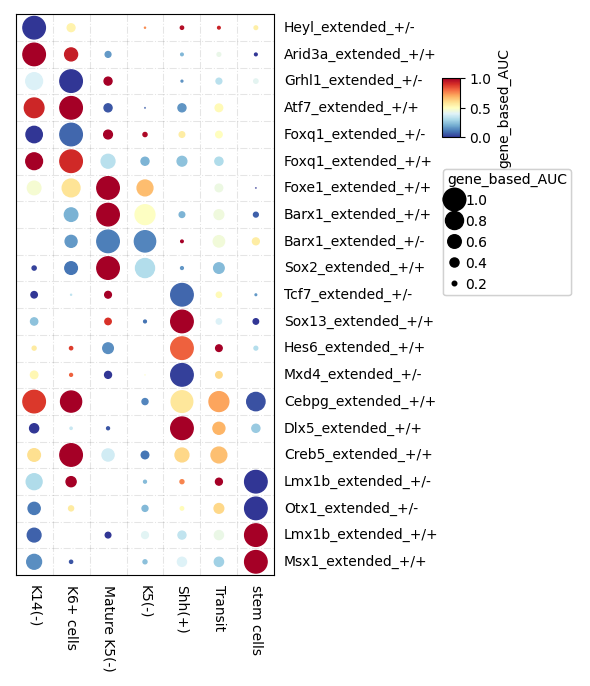

In [27]:

sizeMat = scplus_mdata["extended_gene_based_AUC"].to_df()
colorMat = scplus_mdata["extended_region_based_AUC"].to_df()
group_by = scplus_mdata.obs["scRNA_counts:knn_label"].tolist()
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
size_features = regulon_metadata["Region_signature_name"].tolist()
color_features = regulon_metadata["Gene_signature_name"].tolist()
feature_names = regulon_metadata["eRegulon_name"].tolist()
# First, check the actual column names in your matrices
from scenicplus.plotting.dotplot import generate_dotplot_df
# First, check the actual column names in your matrices
print("Size matrix columns:", sizeMat.columns[:5])  # Print first 5 columns
print("Color matrix columns:", colorMat.columns[:5])

# Check the feature names you're trying to use
print("Size features (first 5):", size_features[:5])
print("Color features (first 5):", color_features[:5])

# Get the correct feature names from metadata
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
print("Metadata columns:", regulon_metadata.columns)

# Make sure features match exactly
size_features = regulon_metadata["Gene_signature_name"].drop_duplicates().tolist()
color_features = regulon_metadata["Region_signature_name"].drop_duplicates().tolist()
feature_names = regulon_metadata["eRegulon_name"].drop_duplicates().tolist()

# Verify features exist in matrices
common_size_features = [f for f in size_features if f in sizeMat.columns]
common_color_features = [f for f in color_features if f in colorMat.columns]

# Now try generate_dotplot_df with verified features
dotplot_df = generate_dotplot_df(
    size_matrix=sizeMat,
    color_matrix=colorMat,
    group_by=group_by,
    size_features=common_size_features,
    color_features=common_color_features,
    feature_names=feature_names[:len(common_size_features)],  # Make sure lengths match
    scale_size_matrix=True,
    scale_color_matrix=True,
    group_name="knn_label",
    size_name="direct_gene_based_AUC",
    color_name="direct_region_based_AUC",
    feature_name="eRegulon"
)
sizeMat = scplus_mdata["extended_gene_based_AUC"].to_df()
colorMat = scplus_mdata["extended_region_based_AUC"].to_df()
group_by = scplus_mdata.obs["scRNA_counts:knn_label"].tolist()
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
size_features = regulon_metadata["Region_signature_name"].tolist()
color_features = regulon_metadata["Gene_signature_name"].tolist()
feature_names = regulon_metadata["eRegulon_name"].tolist()
# First, check the actual column names in your matrices
print("Size matrix columns:", sizeMat.columns[:5])  # Print first 5 columns
print("Color matrix columns:", colorMat.columns[:5])

# Check the feature names you're trying to use
print("Size features (first 5):", size_features[:5])
print("Color features (first 5):", color_features[:5])

# Get the correct feature names from metadata
regulon_metadata = scplus_mdata.uns["extended_e_regulon_metadata"]
print("Metadata columns:", regulon_metadata.columns)

# Make sure features match exactly
size_features = regulon_metadata["Gene_signature_name"].drop_duplicates().tolist()
color_features = regulon_metadata["Region_signature_name"].drop_duplicates().tolist()
feature_names = regulon_metadata["eRegulon_name"].drop_duplicates().tolist()

# Verify features exist in matrices
common_size_features = [f for f in size_features if f in sizeMat.columns]
common_color_features = [f for f in color_features if f in colorMat.columns]

# Now try generate_dotplot_df with verified features
dotplot_df_extend = generate_dotplot_df(
    size_matrix=sizeMat,
    color_matrix=colorMat,
    group_by=group_by,
    size_features=common_size_features,
    color_features=common_color_features,
    feature_names=feature_names[:len(common_size_features)],  # Make sure lengths match
    scale_size_matrix=True,
    scale_color_matrix=True,
    group_name="knn_label",
    size_name="extended_gene_based_AUC",
    color_name="extended_region_based_AUC",
    feature_name="eRegulon"
)
dotplot_df.columns = ['knn_label', 'region_based_AUC', 'eRegulon',
       'gene_based_AUC']
dotplot_df_extend.columns = ['knn_label', 'region_based_AUC', 'eRegulon',
       'gene_based_AUC']
dotplot_concat = pd.concat([dotplot_df,dotplot_df_extend],axis=0)
import pandas as pd

# Assuming your dataframe is called 'df'
result = {}
df = rss_transpose
columnOrder = ['K14(-)','K6+ cells','Mature K5(-) ','K5(-)','Shh(+)','Transit','stem cells']

df_activators = df[df.index.str.contains('_\+/')]  # This keeps rows where eRegulon contains '+/'
df_activators = df_activators.loc[:,columnOrder]
for column in df_activators.columns:
    # Sort values in descending order and get top 5
    top_5 = df_activators[column].sort_values(ascending=False).head(5)
    result[column] = {
        'regulons': list(top_5.index),
        'values': list(top_5.values)
    }

regulonList_top3 = []
for column, data in result.items():
    for regulon, value in zip(data['regulons'], data['values']):
        if regulon not in regulonList_top3:
            regulonList_top3.append(regulon)
cleaned_list_top3 = [x.split('_(')[0] for x in regulonList_top3]
cleaned_list_top3 = ["Arid3a_extended_+/-"] + cleaned_list_top3
cleaned_list_top3 
dotplot_concat_filter_top3 = dotplot_concat[dotplot_concat.eRegulon.isin(cleaned_list_top3)]

cleaned_list_top3 = [x for x in cleaned_list_top3 if x in dotplot_concat_filter_top3['eRegulon'].values]

dotplot_concat_filter_top3['knn_label'] = pd.Categorical(dotplot_concat_filter_top3['knn_label'], 
                                categories=columnOrder, 
                                ordered=True)
dotplot_concat_filter_top3['eRegulon'] = pd.Categorical(dotplot_concat_filter_top3['eRegulon'], 
                                categories=cleaned_list_top3, 
                                ordered=True)
# Sort the DataFrame
dotplot_concat_filter_top3_sorted = dotplot_concat_filter_top3.sort_values('eRegulon')
dotplot_concat_filter_top3_sorted = dotplot_concat_filter_top3_sorted.sort_values('knn_label')

plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=dotplot_concat_filter_top3_sorted,
    x='knn_label',          # Column names
    y='eRegulon',
    value='gene_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=False,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.savefig("../result/regulation/20241226_scenicplus_paired/20250225_top5_regulon.pdf")
plt.tight_layout()

Size matrix columns: Index(['Acaa1b_extended_+/+_(12g)', 'Ahr_extended_+/-_(123g)',
       'Arid3a_extended_+/+_(84g)', 'Arid5b_extended_+/+_(29g)',
       'Arid5b_extended_+/-_(18g)'],
      dtype='object')
Color matrix columns: Index(['Acaa1b_extended_+/+_(14r)', 'Ahr_extended_+/-_(169r)',
       'Arid3a_extended_+/+_(117r)', 'Arid5b_extended_+/+_(36r)',
       'Arid5b_extended_+/-_(23r)'],
      dtype='object')
Size features (first 5): ['Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)', 'Atf3_direct_+/+_(1302r)']
Color features (first 5): ['Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)', 'Atf3_direct_+/+_(485g)']
Metadata columns: Index(['Region', 'Gene', 'importance_R2G', 'rho_R2G', 'importance_x_rho',
       'importance_x_abs_rho', 'TF', 'is_extended', 'eRegulon_name',
       'Gene_signature_name', 'Region_signature_name', 'importance_TF2G',
       'regulation', 'rho_TF2

/tmp/ipykernel_2191701/2289329697.py:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2191701/2289329697.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:356: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
/home/zhanglab/micromamba/envs

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 120.30707788647567
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/tmp/ipykernel_2191701/2289329697.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


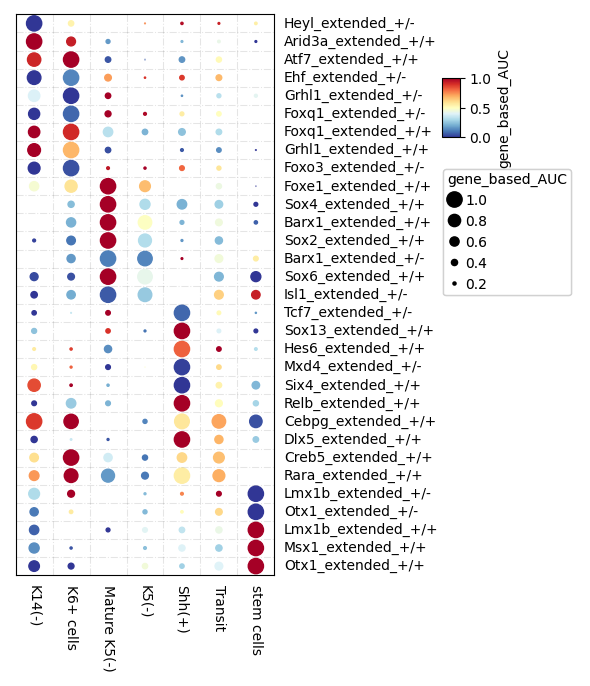

In [29]:

sizeMat = scplus_mdata["extended_gene_based_AUC"].to_df()
colorMat = scplus_mdata["extended_region_based_AUC"].to_df()
group_by = scplus_mdata.obs["scRNA_counts:knn_label"].tolist()
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
size_features = regulon_metadata["Region_signature_name"].tolist()
color_features = regulon_metadata["Gene_signature_name"].tolist()
feature_names = regulon_metadata["eRegulon_name"].tolist()
# First, check the actual column names in your matrices
from scenicplus.plotting.dotplot import generate_dotplot_df
# First, check the actual column names in your matrices
print("Size matrix columns:", sizeMat.columns[:5])  # Print first 5 columns
print("Color matrix columns:", colorMat.columns[:5])

# Check the feature names you're trying to use
print("Size features (first 5):", size_features[:5])
print("Color features (first 5):", color_features[:5])

# Get the correct feature names from metadata
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
print("Metadata columns:", regulon_metadata.columns)

# Make sure features match exactly
size_features = regulon_metadata["Gene_signature_name"].drop_duplicates().tolist()
color_features = regulon_metadata["Region_signature_name"].drop_duplicates().tolist()
feature_names = regulon_metadata["eRegulon_name"].drop_duplicates().tolist()

# Verify features exist in matrices
common_size_features = [f for f in size_features if f in sizeMat.columns]
common_color_features = [f for f in color_features if f in colorMat.columns]

# Now try generate_dotplot_df with verified features
dotplot_df = generate_dotplot_df(
    size_matrix=sizeMat,
    color_matrix=colorMat,
    group_by=group_by,
    size_features=common_size_features,
    color_features=common_color_features,
    feature_names=feature_names[:len(common_size_features)],  # Make sure lengths match
    scale_size_matrix=True,
    scale_color_matrix=True,
    group_name="knn_label",
    size_name="direct_gene_based_AUC",
    color_name="direct_region_based_AUC",
    feature_name="eRegulon"
)
sizeMat = scplus_mdata["extended_gene_based_AUC"].to_df()
colorMat = scplus_mdata["extended_region_based_AUC"].to_df()
group_by = scplus_mdata.obs["scRNA_counts:knn_label"].tolist()
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
size_features = regulon_metadata["Region_signature_name"].tolist()
color_features = regulon_metadata["Gene_signature_name"].tolist()
feature_names = regulon_metadata["eRegulon_name"].tolist()
# First, check the actual column names in your matrices
print("Size matrix columns:", sizeMat.columns[:5])  # Print first 5 columns
print("Color matrix columns:", colorMat.columns[:5])

# Check the feature names you're trying to use
print("Size features (first 5):", size_features[:5])
print("Color features (first 5):", color_features[:5])

# Get the correct feature names from metadata
regulon_metadata = scplus_mdata.uns["extended_e_regulon_metadata"]
print("Metadata columns:", regulon_metadata.columns)

# Make sure features match exactly
size_features = regulon_metadata["Gene_signature_name"].drop_duplicates().tolist()
color_features = regulon_metadata["Region_signature_name"].drop_duplicates().tolist()
feature_names = regulon_metadata["eRegulon_name"].drop_duplicates().tolist()

# Verify features exist in matrices
common_size_features = [f for f in size_features if f in sizeMat.columns]
common_color_features = [f for f in color_features if f in colorMat.columns]

# Now try generate_dotplot_df with verified features
dotplot_df_extend = generate_dotplot_df(
    size_matrix=sizeMat,
    color_matrix=colorMat,
    group_by=group_by,
    size_features=common_size_features,
    color_features=common_color_features,
    feature_names=feature_names[:len(common_size_features)],  # Make sure lengths match
    scale_size_matrix=True,
    scale_color_matrix=True,
    group_name="knn_label",
    size_name="extended_gene_based_AUC",
    color_name="extended_region_based_AUC",
    feature_name="eRegulon"
)
dotplot_df.columns = ['knn_label', 'region_based_AUC', 'eRegulon',
       'gene_based_AUC']
dotplot_df_extend.columns = ['knn_label', 'region_based_AUC', 'eRegulon',
       'gene_based_AUC']
dotplot_concat = pd.concat([dotplot_df,dotplot_df_extend],axis=0)
import pandas as pd

# Assuming your dataframe is called 'df'
result = {}
df = rss_transpose
columnOrder = ['K14(-)','K6+ cells','Mature K5(-) ','K5(-)','Shh(+)','Transit','stem cells']

df_activators = df[df.index.str.contains('_\+/')]  # This keeps rows where eRegulon contains '+/'
df_activators = df_activators.loc[:,columnOrder]
for column in df_activators.columns:
    # Sort values in descending order and get top 5
    top_5 = df_activators[column].sort_values(ascending=False).head(8)
    result[column] = {
        'regulons': list(top_5.index),
        'values': list(top_5.values)
    }

regulonList_top3 = []
for column, data in result.items():
    for regulon, value in zip(data['regulons'], data['values']):
        if regulon not in regulonList_top3:
            regulonList_top3.append(regulon)
cleaned_list_top3 = [x.split('_(')[0] for x in regulonList_top3]
cleaned_list_top3 = ["Arid3a_extended_+/-"] + cleaned_list_top3
cleaned_list_top3 
dotplot_concat_filter_top3 = dotplot_concat[dotplot_concat.eRegulon.isin(cleaned_list_top3)]

cleaned_list_top3 = [x for x in cleaned_list_top3 if x in dotplot_concat_filter_top3['eRegulon'].values]

dotplot_concat_filter_top3['knn_label'] = pd.Categorical(dotplot_concat_filter_top3['knn_label'], 
                                categories=columnOrder, 
                                ordered=True)
dotplot_concat_filter_top3['eRegulon'] = pd.Categorical(dotplot_concat_filter_top3['eRegulon'], 
                                categories=cleaned_list_top3, 
                                ordered=True)
# Sort the DataFrame
dotplot_concat_filter_top3_sorted = dotplot_concat_filter_top3.sort_values('eRegulon')
dotplot_concat_filter_top3_sorted = dotplot_concat_filter_top3_sorted.sort_values('knn_label')

plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=dotplot_concat_filter_top3_sorted,
    x='knn_label',          # Column names
    y='eRegulon',
    value='gene_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=False,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()
plt.savefig("../result/regulation/20241226_scenicplus_paired/20250225_top8_regulon.pdf")


## Pertubation

In [150]:
import mudata
import os
import scanpy as sc
import anndata
import matplotlib
import matplotlib.pyplot as plt
import adjustText
import numpy as np
import pandas as pd

In [151]:
from scenicplus.simulation import (
    train_gene_expression_models,
    simulate_perturbation,
    plot_perturbation_effect_in_embedding
)

In [152]:
%matplotlib inline

In [154]:
gene_tf_direct_extended = pd.concat(
    [
        scplus_mdata.uns["direct_e_regulon_metadata"][["Gene", "TF"]].drop_duplicates(),
        scplus_mdata.uns["extended_e_regulon_metadata"][["Gene", "TF"]].drop_duplicates()
    ]
).drop_duplicates()
gene_to_TF = gene_tf_direct_extended.groupby("Gene")["TF"].apply(lambda tfs: list(tfs)).to_dict()

In [200]:
gene_to_TF = gene_tf_direct_extended.groupby("Gene")["TF"].apply(lambda tfs: list(tfs)).to_dict()

In [157]:
genes_to_use = scplus_mdata.uns["direct_e_regulon_metadata"].sort_values("triplet_rank")["Gene"].iloc[0:5_000].drop_duplicates()

In [ ]:
regressors = train_gene_expression_models(
    df_EXP = scplus_mdata["scRNA_counts"].to_df(),
    gene_to_TF = gene_to_TF,
    genes = genes_to_use,
)

  3%|▎         | 62/2374 [03:29<1:59:07,  3.09s/it]

In [ ]:
perturbation_over_iter = simulate_perturbation(
    df_EXP = scplus_mdata["scRNA_counts"].to_df(),
    perturbation = {"Arid3a": 0},
    keep_intermediate = True,
    n_iter = 5,
    regressors = regressors
)

##### perturbation_over_iter

/tmp/ipykernel_1418005/3258187684.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  baseline = perturbation_over_iter[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean().loc[cell_line, genes_to_show]
/tmp/ipykernel_1418005/3258187684.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  np.log2(perturbation_over_iter[i].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean().loc[cell_line, gene] / baseline[gene])
/tmp/ipykernel_1418005/3258187684.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

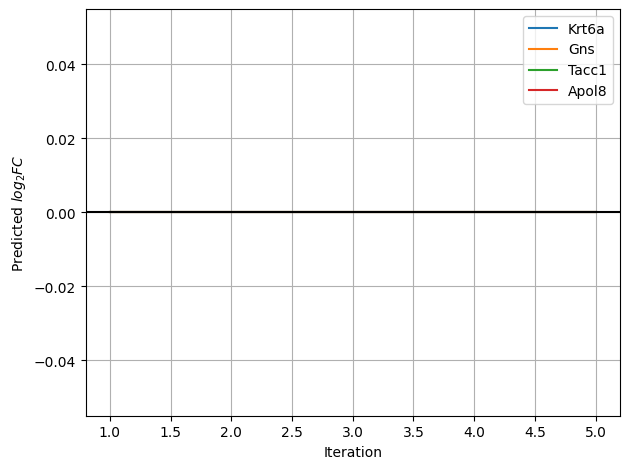

In [163]:
genes_to_show = ["Krt6a","Gns","Tacc1","Apol8"]
cell_line = "K14(-)"
fig, ax = plt.subplots()
baseline = perturbation_over_iter[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean().loc[cell_line, genes_to_show]
for gene in genes_to_show:
    ax.plot(
        np.arange(5) + 1,
        [
            np.log2(perturbation_over_iter[i].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean().loc[cell_line, gene] / baseline[gene])
            for i in np.arange(5) + 1
        ],
        label = gene
    )
ax.set_ylabel("Predicted $log{_2}FC$")
ax.set_xlabel("Iteration")
ax.legend()
ax.axhline(y = 0, color = "black")
ax.grid("gray")
ax.set_axisbelow(True)

In [175]:
pertubate_0 = perturbation_over_iter[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()

/tmp/ipykernel_1418005/1287788132.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pertubate_0 = perturbation_over_iter[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()


In [176]:
pertubate_5 = perturbation_over_iter[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()

/tmp/ipykernel_1418005/769707320.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pertubate_5 = perturbation_over_iter[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()


In [177]:
pertubate_5

,Xkr4,Gm1992,Rp1,Sox17,Mrpl15,Lypla1,Gm37988,Tcea1,Rgs20,Gm16041,...,Olfr1462,Olfr1487,Olfr1491,Olfr1497,Olfr1500,Olfr1501,4933411K16Rik,Gm10197,Gm26874,AC132444.1
scRNA_counts:knn_label,,,,,,,,,,,,,,,,,,,,,
K5(-),0.194479,0.002116,0.000000,0.000000,2.201597,0.833029,0.010580,2.682120,0.008753,0.000385,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.00000
K6+ cells,0.183923,0.001311,0.000000,0.000000,2.246833,0.696374,0.005242,2.500218,0.022280,0.000000,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.00000
K14(-),0.387324,0.014085,0.000000,0.000000,1.760563,0.376761,0.000000,1.482394,0.003521,0.000000,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.00000
Mature K5(-),0.034167,0.000000,0.000000,0.000000,1.221782,0.692495,0.001220,1.637584,0.002746,0.000000,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.001525,0.00000
Shh(+),0.046163,0.000000,0.000000,0.002495,2.408609,0.696195,0.003119,2.250156,0.011853,0.000000,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.00000
Transit,0.145524,0.002435,0.000125,0.000499,2.608565,0.766700,0.011175,2.828256,0.021164,0.000562,...,0.0,0.0,0.0,0.0,0.00025,0.0,0.0,0.0,0.000000,0.00025
stem cells,0.112349,0.002462,0.000389,0.000389,1.957885,0.536089,0.022936,1.755734,0.012829,0.000000,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.00000


In [180]:
pertubationMat = pertubate_0 -pertubate_5

In [189]:
sum((pertubationMat!=0).any(axis=0))

0

In [182]:
# Method 1: Remove columns with sum=0 and sort
def clean_and_sort_df(df):
    # Remove columns where sum is 0
    df = df.loc[:, (df != 0).any(axis=0)]
    
    # Sort columns by sum in descending order
    column_sums = df.sum()
    sorted_columns = column_sums.sort_values(ascending=False).index
    df = df[sorted_columns]
    
    return df

In [164]:
eRegulon_gene_AUC

AnnData object with n_obs × n_vars = 41586 × 488
    obs: 'scRNA_counts:orig.ident', 'scRNA_counts:nCount_RNA', 'scRNA_counts:nFeature_RNA', 'scRNA_counts:percent.mt', 'scRNA_counts:nCount_SCT', 'scRNA_counts:nFeature_SCT', 'scRNA_counts:SCT_snn_res.0.8', 'scRNA_counts:seurat_clusters', 'scRNA_counts:group', 'scRNA_counts:SCT_snn_res.0.6', 'scRNA_counts:celltype', 'scRNA_counts:SCT_snn_res.0.4', 'scRNA_counts:S.Score', 'scRNA_counts:G2M.Score', 'scRNA_counts:Phase', 'scRNA_counts:old.ident', 'scRNA_counts:ident', 'scRNA_counts:knn_label', 'scATAC_counts:fraction_of_fragments_in_peaks', 'scATAC_counts:unique_fragments_in_peaks_count', 'scATAC_counts:pdf_values_for_duplication_ratio', 'scATAC_counts:duplication_count', 'scATAC_counts:pdf_values_for_fraction_of_fragments_in_peaks', 'scATAC_counts:sample_id', 'scATAC_counts:cisTopic_nr_acc', 'scATAC_counts:barcode_rank', 'scATAC_counts:log10_total_fragments_in_peaks_count', 'scATAC_counts:log10_total_fragments_count', 'scATAC_counts:cisTop

In [169]:
eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]

Cell
AGCTGATGTCGACTGC-1-E145_1___E145_1            K5(-)
GAAAGTAAGTATGGGC-1-E145_1___E145_1            K5(-)
ATCCCTGAGCTCCATA-1-E125_2___E125_2       stem cells
ACCAAACCATTCACCC-1-E125_2___E125_2    Mature K5(-) 
GCCAGACCATCAGAAA-1-E145_2___E145_2          Transit
                                          ...      
TTGTTCATCATGCTTT-1-E145_2___E145_2           Shh(+)
TACGCAAAGATGGGAA-1-E145_1___E145_1          Transit
TAACAGCTCGTGAGTT-1-E125_2___E125_2          Transit
ACGTTAGTCCGATTGA-1-E125_2___E125_2          Transit
GGCGTTGAGGGATCCA-1-E145_1___E145_1    Mature K5(-) 
Name: scRNA_counts:knn_label, Length: 41586, dtype: category
Categories (7, object): ['K5(-)', 'K6+ cells', 'K14(-)', 'Mature K5(-) ', 'Shh(+)', 'Transit', 'stem cells']

In [241]:
color_dict_line = {
    'K5(-)': '#F2C9D5',
    'K6+ cells': '#B43E44',
    'K14(-)': '#282828',
    'Mature K5(-) ': '#8B6D9C',
    'Shh(+)': '#496496',
    'Transit': '#FADF92',
    'stem cells': '#904869'}


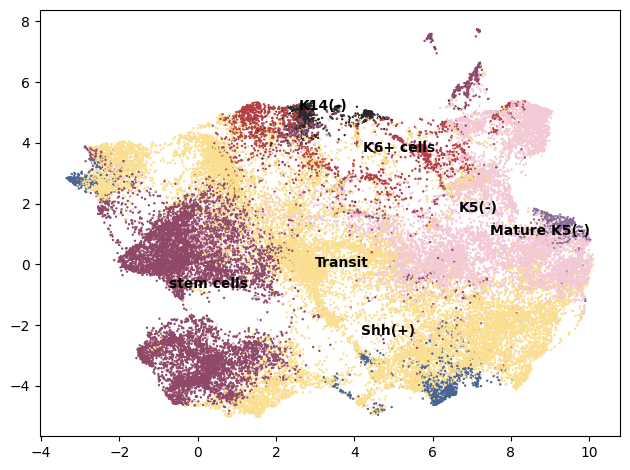

In [243]:
def plot_mm_line_pca(ax, point_size=1):  # Added point_size parameter with default value
    texts = []
    # Plot PCA with smaller points
    ax.scatter(
        eRegulon_gene_AUC.obsm["X_umap_snap"][:, 0],
        eRegulon_gene_AUC.obsm["X_umap_snap"][:, 1],
        s=point_size,  # Add size parameter
        color=[color_dict_line[line] for line in eRegulon_gene_AUC.obs["scATAC_counts:knn_label"]]
    )
    # Plot labels
    for line in set(eRegulon_gene_AUC.obs["scATAC_counts:knn_label"]):
        line_bc_idc = np.arange(len(eRegulon_gene_AUC.obs_names))[eRegulon_gene_AUC.obs["scATAC_counts:knn_label"] == line]
        avg_x, avg_y = eRegulon_gene_AUC.obsm["X_umap_snap"][line_bc_idc, 0:2].mean(0)
        texts.append(
            ax.text(
                avg_x,
                avg_y,
                line,
                fontweight="bold"
            )
        )
    adjustText.adjust_text(texts)

# Usage examples:
fig, ax = plt.subplots()
plot_mm_line_pca(ax, point_size=0.5)  # Very small points

2024-12-30 05:30:25,927 Perturbation INFO     Generating ranking based on perturbed matrix.
2024-12-30 05:33:27,220 Perturbation INFO     Scoring eRegulons.


/home/zhanglab/micromamba/envs/py311/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

If you really know what your doing, you can silence this warning with the warning module
or by setting POLARS_ALLOW_FORKING_THREAD=1.

  self.pid = os.fork()
/home/zhanglab/micromamba/envs/py311/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The 

2024-12-30 05:35:28,884 Perturbation INFO     Projecting perturbation effect in embedding


/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scenicplus/simulation.py:232: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


2024-12-30 09:36:46,867 Perturbation INFO     Calculating grid of arrows
2024-12-30 09:36:47,047 Perturbation INFO     Plotting


<AxesSubplot: >

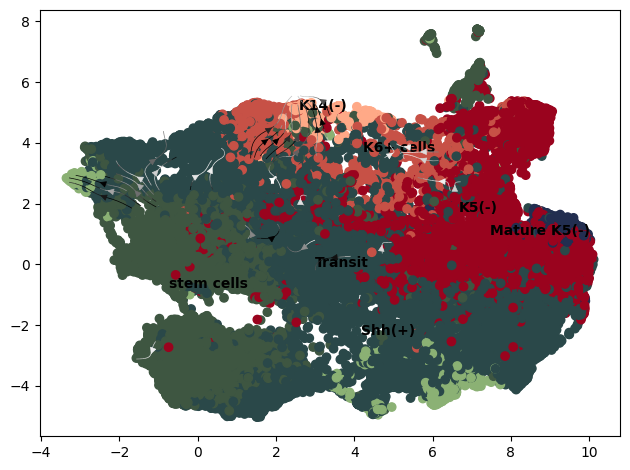

In [173]:
fig, ax = plt.subplots()
plot_mm_line_pca(ax)
plot_perturbation_effect_in_embedding(
    perturbed_matrix = perturbation_over_iter[5],
    original_matrix = perturbation_over_iter[0],
    embedding = eRegulon_gene_AUC.obsm["X_umap_snap"][:, 0:2],
    AUC_kwargs = {},
    ax = ax,
    eRegulons = pd.concat(
        [
            scplus_mdata.uns["direct_e_regulon_metadata"],
            scplus_mdata.uns["extended_e_regulon_metadata"]
        ]
    ),
    n_cpu = 10,
)

In [237]:
genes_to_use2 = scplus_mdata.uns["extended_e_regulon_metadata"].sort_values("triplet_rank")["Gene"].iloc[0:6_000].drop_duplicates()

In [ ]:
regressors2 = train_gene_expression_models(
    df_EXP = scplus_mdata["scRNA_counts"].to_df(),
    gene_to_TF = gene_to_TF,
    genes = genes_to_use2,
)

 36%|███▌      | 973/2728 [56:39<1:35:34,  3.27s/it]

In [244]:
perturbation_over_iter2 = simulate_perturbation(
    df_EXP = scplus_mdata["scRNA_counts"].to_df(),
    perturbation = {"Arid3a": 0},
    keep_intermediate = True,
    n_iter = 5,
    regressors = regressors2
)

In [245]:
pertubate_2_0 = perturbation_over_iter2[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()
pertubate_2_5 = perturbation_over_iter2[5].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()


/tmp/ipykernel_1418005/1345945004.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pertubate_2_0 = perturbation_over_iter2[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()
/tmp/ipykernel_1418005/1345945004.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pertubate_2_5 = perturbation_over_iter2[5].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()


In [246]:
pertubationMat = pertubate_2_0 -pertubate_2_5

In [247]:
sum((pertubationMat!=0).any(axis=0))

24

In [250]:
pertubationMat.index

CategoricalIndex(['K5(-)', 'K6+ cells', 'K14(-)', 'Mature K5(-) ', 'Shh(+)',
                  'Transit', 'stem cells'],
                 categories=['K5(-)', 'K6+ cells', 'K14(-)', 'Mature K5(-) ', 'Shh(+)', 'Transit', 'stem cells'], ordered=False, dtype='category', name='scRNA_counts:knn_label')

In [251]:
pertubationMat.columns[(pertubationMat!=0).any(axis=0)]

Index(['Slc52a3', 'Cox4i2', 'Cdkl5', 'Tnik', 'Gpr87', 'Ccser1', 'Adam12',
       'Frk', 'Cstb', 'Arid3a', 'Gns', 'Tacc1', 'Palm3', 'Tgm1', 'Wwc1',
       'Chrm3', 'Pygl', 'Snx31', 'Micall1', 'Arhgap8', 'Itga5', 'Gal', 'Cd248',
       'Tjp2'],
      dtype='object')

/tmp/ipykernel_1418005/2601614024.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  baseline = perturbation_over_iter2[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean().loc[cell_line, genes_to_show]
/tmp/ipykernel_1418005/2601614024.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  np.log2(perturbation_over_iter2[i].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean().loc[cell_line, gene] / baseline[gene])
/tmp/ipykernel_1418005/2601614024.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fa

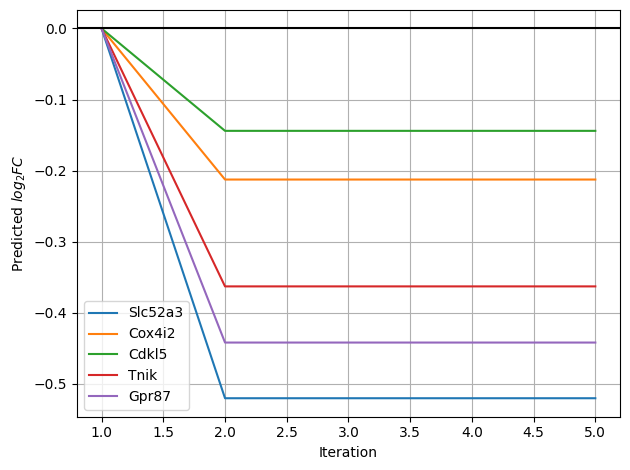

In [252]:
genes_to_show = ['Slc52a3', 'Cox4i2', 'Cdkl5', 'Tnik', 'Gpr87']
cell_line = "K14(-)"
fig, ax = plt.subplots()
baseline = perturbation_over_iter2[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean().loc[cell_line, genes_to_show]
for gene in genes_to_show:
    ax.plot(
        np.arange(5) + 1,
        [
            np.log2(perturbation_over_iter2[i].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean().loc[cell_line, gene] / baseline[gene])
            for i in np.arange(5) + 1
        ],
        label = gene
    )
ax.set_ylabel("Predicted $log{_2}FC$")
ax.set_xlabel("Iteration")
ax.legend()
ax.axhline(y = 0, color = "black")
ax.grid("gray")
ax.set_axisbelow(True)

2025-01-01 06:58:11,859 Perturbation INFO     Generating ranking based on perturbed matrix.
2025-01-01 07:01:01,880 Perturbation INFO     Scoring eRegulons.
2025-01-01 07:03:08,515 Perturbation INFO     Projecting perturbation effect in embedding


/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scenicplus/simulation.py:232: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


2025-01-01 10:43:32,480 Perturbation INFO     Calculating grid of arrows
2025-01-01 10:43:32,753 Perturbation INFO     Plotting


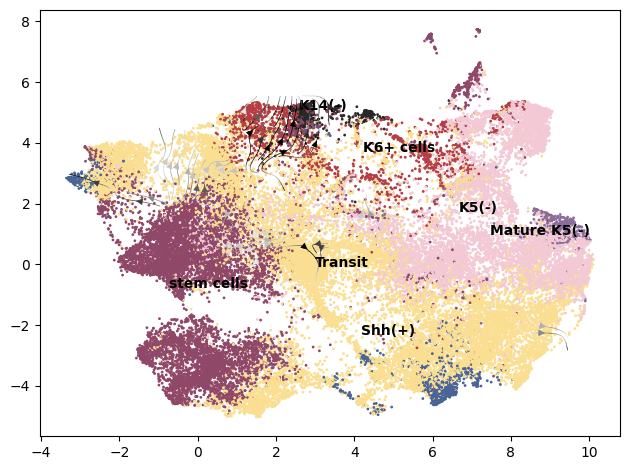

In [254]:
fig, ax = plt.subplots()
plot_mm_line_pca(ax)
plot_perturbation_effect_in_embedding(
    perturbed_matrix = perturbation_over_iter2[5],
    original_matrix = perturbation_over_iter2[0],
    embedding = eRegulon_gene_AUC.obsm["X_umap_snap"][:, 0:2],
    AUC_kwargs = {},
    ax = ax,
    eRegulons = pd.concat(
        [
            scplus_mdata.uns["direct_e_regulon_metadata"],
            scplus_mdata.uns["extended_e_regulon_metadata"]
        ]
    ),
    n_cpu = 30
)
plt.savefig("../result/regulation/20250101_scenicplus_purtubation/20250101_arid3a_pertubation.pdf")

In [ ]:
perturbation_over_iter3 = simulate_perturbation(
    df_EXP = scplus_mdata["scRNA_counts"].to_df(),
    perturbation = {"Grhl1": 0},
    keep_intermediate = True,
    n_iter = 5,
    regressors = regressors2
)

In [258]:
pertubate_3_0 = perturbation_over_iter3[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()
pertubate_3_5 = perturbation_over_iter3[5].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()


/tmp/ipykernel_1418005/3962915182.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pertubate_3_0 = perturbation_over_iter3[0].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()
/tmp/ipykernel_1418005/3962915182.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pertubate_3_5 = perturbation_over_iter3[5].groupby(eRegulon_gene_AUC.obs["scRNA_counts:knn_label"]).mean()


In [259]:
pertubationMatGrhl1 = pertubate_3_0 -pertubate_3_5
sum((pertubationMatGrhl1!=0).any(axis=0))

1609

In [260]:
pertubationMatGrhl1.columns[(pertubationMatGrhl1!=0).any(axis=0)]

Index(['Mrpl15', 'Atp6v1h', 'Cops5', 'Cpa6', 'A830018L16Rik', 'Eya1', 'Jph1',
       'Tfap2b', 'Khdrbs2', 'Arhgef4',
       ...
       'Col17a1', 'Sfr1', 'Gsto1', 'Smc3', 'Ablim1', 'Shtn1', 'Rab11fip2',
       'Eif3a', 'Csf2ra', 'Clec2e'],
      dtype='object', length=1609)

In [ ]:
fig, ax = plt.subplots()
plot_mm_line_pca(ax)
plot_perturbation_effect_in_embedding(
    perturbed_matrix = perturbation_over_iter3[5],
    original_matrix = perturbation_over_iter3[0],
    embedding = eRegulon_gene_AUC.obsm["X_umap_snap"][:, 0:2],
    AUC_kwargs = {},
    ax = ax,
    eRegulons = pd.concat(
        [
            scplus_mdata.uns["direct_e_regulon_metadata"],
            scplus_mdata.uns["extended_e_regulon_metadata"]
        ]
    ),
    n_cpu = 30
)
plt.savefig("../result/regulation/20250101_scenicplus_purtubation/20250101_Grhl1_pertubation.pdf")